In [1]:
# Step 0: Import Necessary Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras import models


import matplotlib.pyplot as plt
import time
import os
import zipfile
import random
import numpy as np

In [2]:
# Step 1: Set Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Step 2: Load and Prepare the Dataset
# Path to the unzipped data folder
data_dir = r"D:\UNIVERSITY\5th smester\DEEP LEARNING\PROJECT\archive (1)"  # Update with your unzipped folder path

# Check if the directory exists
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Directory not found: {data_dir}")

print(f"Data directory set to: {data_dir}")

Data directory set to: D:\UNIVERSITY\5th smester\DEEP LEARNING\PROJECT\archive (1)


In [4]:

# Define dataset paths
train_dir = r"D:\UNIVERSITY\5th smester\DEEP LEARNING\PROJECT\archive (1)\asl_alphabet_train\asl_alphabet_train"
val_dir = r"D:\UNIVERSITY\5th smester\DEEP LEARNING\PROJECT\archive (1)\asl_alphabet_test\asl_alphabet_test"


# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load training and validation data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),  # Change to 128x128 for consistency
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),  # Ensure consistency with training data
    batch_size=32,
    class_mode='categorical'
)
# Number of classes
num_classes = train_data.num_classes



Found 87000 images belonging to 29 classes.
Found 29 images belonging to 29 classes.


In [5]:
# Load pre-trained MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),  # Smaller input shape
    include_top=False,         # Exclude the default classification layer
    weights='imagenet'         # Use pre-trained weights
)

# Freeze the base model's layers to retain pre-trained weights
base_model.trainable = False

# Add custom classification head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  # Pooling layer to reduce dimensions
    Dropout(0.6),              # Dropout to prevent overfitting
    Dense(256, activation='relu'),  # Fully connected layer
    Dropout(0.6),
    Dense(num_classes, activation='softmax')  # Output layer with 29 classes
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    callbacks=[lr_scheduler],
    verbose=1
)



c:\Users\Admin\anaconda3\envs\py311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1900s 694ms/step - accuracy: 0.2331 - loss: 2.7370 - val_accuracy: 0.1724 - val_loss: 9.5800 - learning_rate: 0.0010
Epoch 2/10
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1220s 449ms/step - accuracy: 0.4421 - loss: 1.8193 - val_accuracy: 0.1724 - val_loss: 12.2033 - learning_rate: 0.0010
Epoch 3/10
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.4726 - loss: 1.7110
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1402s 516ms/step - accuracy: 0.4726 - loss: 1.7110 - val_accuracy: 0.1724 - val_loss: 13.0623 - learning_rate: 0.0010
Epoch 4/10
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1363s 501ms/step - accuracy: 0.4964 - loss: 1.6307 - val_accuracy: 0.1724 - val_loss: 14.3032 - learning_rate: 5.0000e-04
Epoch 5/10
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.5151 - loss: 1.5664
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1433s

In [7]:
# Fine-tune the base model
base_model.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    verbose=1
)

Epoch 1/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 5045s 2s/step - accuracy: 0.3500 - loss: 2.8266 - val_accuracy: 0.1724 - val_loss: 20.6763
Epoch 2/5
 951/2719 ━━━━━━━━━━━━━━━━━━━━ 52:09 2s/step - accuracy: 0.6436 - loss: 1.1453

KeyboardInterrupt: 

In [9]:
# Step 6: Evaluate the Model
test_loss, test_acc = model.evaluate(val_data)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.1724 - loss: 21.7309
Test Accuracy: 17.24%


In [ ]:
# Step 7: Save the Model
model.save("final_sign_language_model.h5")


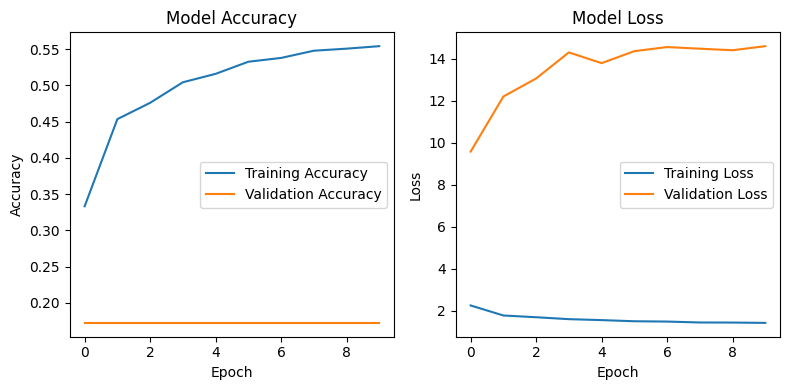

In [10]:
# Step 8: Plot Accuracy and Loss
plt.figure(figsize=(8, 4))
# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()